# Residual Directional Fourier Coefficient Prediction Model

This model predicts residual higher-order directional Fourier coefficients (Δa3, Δb3, Δa4, Δb4, Δa5, Δb5) from input features (S1D, a1, b1, a2, b2). Since the baseline only includes up to 2nd harmonics, the residuals for 3rd-5th harmonics are the full coefficient values.

In [1]:
# Residual Directional Fourier Coefficient Model for ERA5 Wave Spectra
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data (same as dir.ipynb)
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30)
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30)
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")
print(f"b2: {b2.shape}")

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")
print(f"NaN values in b2: {np.isnan(b2).sum()}")

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19100\1179807605.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [3]:
# Compute residual target coefficients from 2D spectra
print("Computing residual Fourier coefficients from 2D spectra...")

def compute_fourier_coefficients(S2D, n_dir=24, max_harmonic=5):
    """Compute Fourier coefficients up to max_harmonic from 2D spectrum"""
    batch_size, n_freq = S2D.shape[0], S2D.shape[1]
    
    # ERA5 directional grid - midpoints: 7.5°, 22.5°, ..., 352.5°
    direction_deg = 7.5 + 15 * np.arange(n_dir)
    theta = np.deg2rad(direction_deg)
    dtheta = 2 * np.pi / n_dir
    
    # Initialize coefficient arrays
    coefficients = {}
    for n in range(1, max_harmonic + 1):
        coefficients[f'a{n}'] = np.zeros((batch_size, n_freq))
        coefficients[f'b{n}'] = np.zeros((batch_size, n_freq))
    
    # Compute 1D spectrum by integrating over directions
    S1D_computed = np.trapezoid(S2D, dx=dtheta, axis=2)
    
    for i in range(batch_size):
        for j in range(n_freq):
            if S1D_computed[i, j] > 1e-15:  # Only process non-zero frequencies
                # Normalized directional distribution
                D = S2D[i, j, :] / S1D_computed[i, j]
                
                # Compute Fourier coefficients for each harmonic
                for n in range(1, max_harmonic + 1):
                    # Fourier integrals
                    a_n = np.trapezoid(D * np.cos(n * theta), dx=dtheta)
                    b_n = np.trapezoid(D * np.sin(n * theta), dx=dtheta)
                    
                    coefficients[f'a{n}'][i, j] = a_n
                    coefficients[f'b{n}'][i, j] = b_n
    
    return coefficients, S1D_computed

# Compute all Fourier coefficients
coefficients, S1D_computed = compute_fourier_coefficients(S2D)

# Extract coefficients for validation
a1_computed = coefficients['a1']
b1_computed = coefficients['b1']
a2_computed = coefficients['a2']
b2_computed = coefficients['b2']

# Extract true higher-order coefficients (3rd-5th harmonics)
a3_true = coefficients['a3']
b3_true = coefficients['b3']
a4_true = coefficients['a4']
b4_true = coefficients['b4']
a5_true = coefficients['a5']
b5_true = coefficients['b5']

# Compute residual targets
# Since baseline only includes a1, b1, a2, b2, residuals for higher-order terms are the full coefficients
Delta_a3 = a3_true  # Residual = true - baseline(0) = a3_true
Delta_b3 = b3_true  # Residual = true - baseline(0) = b3_true
Delta_a4 = a4_true  # Residual = true - baseline(0) = a4_true
Delta_b4 = b4_true  # Residual = true - baseline(0) = b4_true
Delta_a5 = a5_true  # Residual = true - baseline(0) = a5_true
Delta_b5 = b5_true  # Residual = true - baseline(0) = b5_true

print(f"Computed residual Fourier coefficients:")
print(f"Δa3 shape: {Delta_a3.shape}")
print(f"Δb3 shape: {Delta_b3.shape}")
print(f"Δa4 shape: {Delta_a4.shape}")
print(f"Δb4 shape: {Delta_b4.shape}")
print(f"Δa5 shape: {Delta_a5.shape}")
print(f"Δb5 shape: {Delta_b5.shape}")

# Verify consistency with input data
print(f"\nConsistency check (input vs computed):")
print(f"S1D error: {np.mean(np.abs(S1D - S1D_computed)):.6e}")
print(f"a1 error: {np.mean(np.abs(a1 - a1_computed)):.6e}")
print(f"b1 error: {np.mean(np.abs(b1 - b1_computed)):.6e}")
print(f"a2 error: {np.mean(np.abs(a2 - a2_computed)):.6e}")
print(f"b2 error: {np.mean(np.abs(b2 - b2_computed)):.6e}")

print(f"\nResidual statistics:")
print(f"Δa3 range: [{Delta_a3.min():.6f}, {Delta_a3.max():.6f}]")
print(f"Δb3 range: [{Delta_b3.min():.6f}, {Delta_b3.max():.6f}]")
print(f"Δa4 range: [{Delta_a4.min():.6f}, {Delta_a4.max():.6f}]")
print(f"Δb4 range: [{Delta_b4.min():.6f}, {Delta_b4.max():.6f}]")
print(f"Δa5 range: [{Delta_a5.min():.6f}, {Delta_a5.max():.6f}]")
print(f"Δb5 range: [{Delta_b5.min():.6f}, {Delta_b5.max():.6f}]")

Computing residual Fourier coefficients from 2D spectra...
Computed residual Fourier coefficients:
Δa3 shape: (9504, 30)
Δb3 shape: (9504, 30)
Δa4 shape: (9504, 30)
Δb4 shape: (9504, 30)
Δa5 shape: (9504, 30)
Δb5 shape: (9504, 30)

Consistency check (input vs computed):
S1D error: 2.940387e-03
a1 error: 8.630481e-03
b1 error: 8.084460e-03
a2 error: 1.903311e-02
b2 error: 6.125555e-03

Residual statistics:
Δa3 range: [-0.923880, 0.923880]
Δb3 range: [-0.923880, 0.923880]
Δa4 range: [-0.866025, 0.866026]
Δb4 range: [-1.000000, 1.000000]
Δa5 range: [-0.991445, 0.991445]
Δb5 range: [-0.991445, 0.991445]


In [4]:
# Prepare data for residual coefficient training
print("Preparing data for residual coefficient prediction...")

# Model inputs: (batch, freq, channels) = (batch, 30, 5)
# Channels: [S1D, a1, b1, a2, b2]
inputs = np.stack([S1D, a1, b1, a2, b2], axis=2)  # Shape: (batch_size, 30, 5)

# Model targets: (batch, freq, channels) = (batch, 30, 6)
# Channels: [Δa3, Δb3, Δa4, Δb4, Δa5, Δb5]
residual_targets = np.stack([Delta_a3, Delta_b3, Delta_a4, Delta_b4, Delta_a5, Delta_b5], axis=2)

print(f"Input shape: {inputs.shape} (batch, freq=30, input_channels=5)")
print(f"Residual target shape: {residual_targets.shape} (batch, freq=30, output_channels=6)")
print(f"Input channels: [S1D, a1, b1, a2, b2]")
print(f"Residual target channels: [Δa3, Δb3, Δa4, Δb4, Δa5, Δb5]")

# Check for NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(residual_targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in residual targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=(1,2))
    target_mask = ~np.isnan(residual_targets).any(axis=(1,2))
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    residual_targets = residual_targets[valid_mask]
    S2D = S2D[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned residual target shape: {residual_targets.shape}")

# Basic statistics
print(f"\nData statistics:")
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Residual target range: [{residual_targets.min():.6f}, {residual_targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Residual target mean: {residual_targets.mean():.6f}, std: {residual_targets.std():.6f}")

Preparing data for residual coefficient prediction...
Input shape: (9504, 30, 5) (batch, freq=30, input_channels=5)
Residual target shape: (9504, 30, 6) (batch, freq=30, output_channels=6)
Input channels: [S1D, a1, b1, a2, b2]
Residual target channels: [Δa3, Δb3, Δa4, Δb4, Δa5, Δb5]
NaN in inputs: 0
NaN in residual targets: 0

Data statistics:
Input range: [-0.991445, 22.504860]
Residual target range: [-1.000000, 1.000000]
Input mean: -0.121308, std: 0.506509
Residual target mean: 0.026248, std: 0.300908


In [5]:
# Normalize data and create train/val/test splits
print("Normalizing data and creating splits...")

# Normalize inputs per channel (feature-wise normalization)
input_mean = inputs.mean(axis=(0, 1), keepdims=True)  # Mean over batch and frequency
input_std = inputs.std(axis=(0, 1), keepdims=True) + 1e-8  # Std over batch and frequency
inputs_norm = (inputs - input_mean) / input_std

# Normalize residual targets per channel 
residual_mean = residual_targets.mean(axis=(0, 1), keepdims=True)
residual_std = residual_targets.std(axis=(0, 1), keepdims=True) + 1e-8
residual_targets_norm = (residual_targets - residual_mean) / residual_std

# Save normalization parameters
os.makedirs("models", exist_ok=True)
np.savez("models/dir_res_normalization.npz", 
         input_mean=input_mean, input_std=input_std,
         residual_mean=residual_mean, residual_std=residual_std)
print(f"💾 Saved normalization parameters to models/dir_res_normalization.npz")

print(f"Input normalization:")
print(f"  Mean shape: {input_mean.shape}, Std shape: {input_std.shape}")
print(f"  Normalized range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")

print(f"Residual target normalization:")
print(f"  Mean shape: {residual_mean.shape}, Std shape: {residual_std.shape}")
print(f"  Normalized range: [{residual_targets_norm.min():.6f}, {residual_targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Chronological order (don't shuffle)
indices = np.arange(n_samples)
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], residual_targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], residual_targets_norm[val_idx] 
X_test, y_test = inputs_norm[test_idx], residual_targets_norm[test_idx]

# Also split original data for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]

print(f"\nData splits:")
print(f"Train: {X_train.shape[0]} samples ({X_train.shape})")
print(f"Val: {X_val.shape[0]} samples ({X_val.shape})")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape})")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

Normalizing data and creating splits...
💾 Saved normalization parameters to models/dir_res_normalization.npz
Input normalization:
  Mean shape: (1, 1, 5), Std shape: (1, 1, 5)
  Normalized range: [-2.614872, 46.798307]
Residual target normalization:
  Mean shape: (1, 1, 6), Std shape: (1, 1, 6)
  Normalized range: [-4.608806, 3.998548]

Data splits:
Train: 6652 samples ((6652, 30, 5))
Val: 1425 samples ((1425, 30, 5))
Test: 1427 samples ((1427, 30, 5))
Using device: cpu


In [6]:
# Define the residual coefficient prediction model
class ResidualCoefficientModel(nn.Module):
    def __init__(self, input_channels=5, output_channels=6, hidden_size=128, num_layers=3, dropout=0.1):
        super(ResidualCoefficientModel, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        
        # Build MLP layers
        layers = []
        
        # Input layer
        layers.append(nn.Linear(input_channels, hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.Dropout(dropout))
        
        # Hidden layers
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(dropout))
        
        # Output layer (no activation - regression)
        layers.append(nn.Linear(hidden_size, output_channels))
        
        self.network = nn.ModuleList(layers)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # x shape: (batch, freq, input_channels)
        batch_size, n_freq, _ = x.shape
        
        # Reshape for processing: (batch * freq, input_channels)
        x = x.reshape(-1, self.input_channels)
        
        # Apply network layers
        for layer in self.network:
            x = layer(x)
        
        # Reshape back: (batch, freq, output_channels)
        x = x.reshape(batch_size, n_freq, self.output_channels)
        
        return x

In [7]:
# Create residual model
model = ResidualCoefficientModel(
    input_channels=5,   # [S1D, a1, b1, a2, b2]
    output_channels=6,  # [Δa3, Δb3, Δa4, Δb4, Δa5, Δb5]
    hidden_size=256,
    num_layers=4,
    dropout=0.1
).to(device)

print(f"Residual Coefficient Model created:")
print(f"Input channels: 5 [S1D, a1, b1, a2, b2]")
print(f"Output channels: 6 [Δa3, Δb3, Δa4, Δb4, Δa5, Δb5]")
print(f"Hidden size: 256")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_batch = X_train_t[:4]
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test input shape: {test_batch.shape}")
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("✅ Residual model architecture defined successfully")

Residual Coefficient Model created:
Input channels: 5 [S1D, a1, b1, a2, b2]
Output channels: 6 [Δa3, Δb3, Δa4, Δb4, Δa5, Δb5]
Hidden size: 256
Number of parameters: 136,198
Test input shape: torch.Size([4, 30, 5])
Test output shape: torch.Size([4, 30, 6])
Test output range: [-5.956775, 5.505893]
Test output has NaN: False
✅ Residual model architecture defined successfully


In [8]:
# Define reconstruction and loss functions for residual approach
def reconstruct_2d_spectrum_residual(S1D, a1, b1, a2, b2, Delta_a3, Delta_b3, Delta_a4, Delta_b4, Delta_a5, Delta_b5, n_dir=24):
    """Reconstruct 2D spectrum using baseline + residual Fourier series representation"""
    batch_size, n_freq = S1D.shape
    
    # Since baseline only includes a1, b1, a2, b2, residuals give us the full higher-order coefficients
    a3 = Delta_a3  # a3 = baseline_a3(0) + Delta_a3 = Delta_a3
    b3 = Delta_b3  # b3 = baseline_b3(0) + Delta_b3 = Delta_b3
    a4 = Delta_a4  # a4 = baseline_a4(0) + Delta_a4 = Delta_a4
    b4 = Delta_b4  # b4 = baseline_b4(0) + Delta_b4 = Delta_b4
    a5 = Delta_a5  # a5 = baseline_a5(0) + Delta_a5 = Delta_a5
    b5 = Delta_b5  # b5 = baseline_b5(0) + Delta_b5 = Delta_b5
    
    # ERA5 directional grid - midpoints: 7.5°, 22.5°, ..., 352.5°
    direction_deg = 7.5 + 15 * torch.arange(n_dir, device=S1D.device)
    theta = torch.deg2rad(direction_deg)[None, None, :]  # Shape: (1, 1, n_dir)
    
    # Compute directional distribution using complete Fourier series
    # D(θ) = 1/(2π) * (1 + 2*a1*cos(θ) + 2*b1*sin(θ) + 2*a2*cos(2θ) + 2*b2*sin(2θ) + ...)
    D = torch.ones(batch_size, n_freq, n_dir, device=S1D.device) / (2 * torch.pi)
    
    # Add each harmonic contribution
    D += (2 / (2 * torch.pi)) * (
        a1.unsqueeze(-1) * torch.cos(theta) +
        b1.unsqueeze(-1) * torch.sin(theta) +
        a2.unsqueeze(-1) * torch.cos(2 * theta) +
        b2.unsqueeze(-1) * torch.sin(2 * theta) +
        a3.unsqueeze(-1) * torch.cos(3 * theta) +
        b3.unsqueeze(-1) * torch.sin(3 * theta) +
        a4.unsqueeze(-1) * torch.cos(4 * theta) +
        b4.unsqueeze(-1) * torch.sin(4 * theta) +
        a5.unsqueeze(-1) * torch.cos(5 * theta) +
        b5.unsqueeze(-1) * torch.sin(5 * theta)
    )
    
    # Ensure non-negative directional distribution
    D = torch.clamp(D, min=0.0)
    
    # Normalize D to integrate to 1 over directions
    dtheta = 2 * torch.pi / n_dir
    D_sum = torch.sum(D, dim=2, keepdim=True) * dtheta
    D = D / torch.clamp(D_sum, min=1e-10)
    
    # Reconstruct 2D spectrum: S(f,θ) = S(f) * D(θ)
    S2D_reconstructed = S1D.unsqueeze(-1) * D
    
    return S2D_reconstructed

def residual_spectrum_loss(pred_residuals, input_features, target_2d):
    """Loss function for residual coefficient prediction - focuses on spectrum reconstruction"""
    # Extract input features
    S1D = input_features[:, :, 0]  # Shape: (batch, freq)
    a1 = input_features[:, :, 1]
    b1 = input_features[:, :, 2]
    a2 = input_features[:, :, 3]
    b2 = input_features[:, :, 4]
    
    # Extract predicted residual coefficients
    Delta_a3 = pred_residuals[:, :, 0]
    Delta_b3 = pred_residuals[:, :, 1]
    Delta_a4 = pred_residuals[:, :, 2]
    Delta_b4 = pred_residuals[:, :, 3]
    Delta_a5 = pred_residuals[:, :, 4]
    Delta_b5 = pred_residuals[:, :, 5]
    
    # Reconstruct 2D spectrum using residual approach
    S2D_pred = reconstruct_2d_spectrum_residual(
        S1D, a1, b1, a2, b2, Delta_a3, Delta_b3, Delta_a4, Delta_b4, Delta_a5, Delta_b5
    )
    
    # Primary loss: MSE between reconstructed and target 2D spectrum
    spectrum_loss = torch.mean((S2D_pred - target_2d)**2)
    
    return spectrum_loss, S2D_pred

In [9]:
# Test residual loss function
print("Testing residual loss function...")
with torch.no_grad():
    # Create test data
    test_pred = model(X_train_t[:4])
    test_input = X_train_t[:4]
    test_target = torch.FloatTensor(S2D_train[:4]).to(device)
    
    # Test loss computation
    spectrum_loss, S2D_pred = residual_spectrum_loss(
        test_pred, test_input, test_target
    )
    
    print(f"Test losses:")
    print(f"  Spectrum MSE: {spectrum_loss.item():.6f}")
    print(f"  Reconstructed shape: {S2D_pred.shape}")
    print(f"  Reconstructed range: [{S2D_pred.min().item():.6f}, {S2D_pred.max().item():.6f}]")
    
    # Check for NaN
    if torch.isnan(spectrum_loss):
        print("WARNING: NaN in loss function!")
    else:
        print("✅ Residual loss function working correctly")

print("Residual loss functions defined successfully")

Testing residual loss function...
Test losses:
  Spectrum MSE: 0.006016
  Reconstructed shape: torch.Size([4, 30, 24])
  Reconstructed range: [-0.348482, 0.361991]
✅ Residual loss function working correctly
Residual loss functions defined successfully


In [10]:
# Training setup for residual model
print("Setting up residual training...")

# Training hyperparameters
learning_rate = 1e-4
batch_size = 32
num_epochs = 50
weight_decay = 1e-5

# Prepare target 2D spectra as tensors
S2D_train_t = torch.FloatTensor(S2D_train).to(device)
S2D_val_t = torch.FloatTensor(S2D_val).to(device)

# Create data loaders
train_dataset = TensorDataset(X_train_t, y_train_t, S2D_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t, S2D_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

print(f"Residual training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

# Training history
train_losses = []
val_losses = []  
best_val_loss = float('inf')

print("Ready to start residual coefficient training")

Setting up residual training...
Residual training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Train batches: 208
  Val batches: 45
Ready to start residual coefficient training


In [11]:
# Residual training loop
model_path = "models/dir_res_model.pth"

print("Starting residual coefficient training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y, batch_target_2d) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass - predict residual coefficients
        pred_residuals = model(batch_x)
        
        # Compute loss using spectrum reconstruction
        spectrum_loss, _ = residual_spectrum_loss(
            pred_residuals, batch_x, batch_target_2d
        )
        
        # Check for NaN
        if torch.isnan(spectrum_loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        # Backward pass
        spectrum_loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_train_loss += spectrum_loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}")
            print(f"    Spectrum Loss: {spectrum_loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_x, batch_y, batch_target_2d in val_loader:
            pred_residuals = model(batch_x)
            spectrum_loss, _ = residual_spectrum_loss(
                pred_residuals, batch_x, batch_target_2d
            )
            
            if not torch.isnan(spectrum_loss):
                epoch_val_loss += spectrum_loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✅ New best residual model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 50)

print("Residual training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting residual coefficient training...
  Batch 50/208
    Spectrum Loss: 0.053235
  Batch 100/208
    Spectrum Loss: 0.011469
  Batch 150/208
    Spectrum Loss: 0.009989
  Batch 200/208
    Spectrum Loss: 0.012808
Epoch 1/50
  Train Loss: 0.050194
  Val Loss: 0.026083
  Learning Rate: 1.00e-04
  ✅ New best residual model saved (val_loss: 0.026083)
--------------------------------------------------
  Batch 50/208
    Spectrum Loss: 0.006909
  Batch 100/208
    Spectrum Loss: 0.061670
  Batch 150/208
    Spectrum Loss: 0.025710
  Batch 200/208
    Spectrum Loss: 0.014382
Epoch 2/50
  Train Loss: 0.046335
  Val Loss: 0.023009
  Learning Rate: 1.00e-04
  ✅ New best residual model saved (val_loss: 0.023009)
--------------------------------------------------
  Batch 50/208
    Spectrum Loss: 0.010622
  Batch 100/208
    Spectrum Loss: 0.094008
  Batch 150/208
    Spectrum Loss: 0.008435
  Batch 200/208
    Spectrum Loss: 0.023062
Epoch 3/50
  Train Loss: 0.045152
  Val Loss: 0.018126
  Le

In [14]:
# Residual model evaluation
print("Evaluating residual coefficient model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Make predictions on test set
with torch.no_grad():
    test_pred_residuals = model(X_test_t)
    
    # Denormalize predicted residuals
    test_pred_residuals_denorm = test_pred_residuals * torch.FloatTensor(residual_std).to(device) + torch.FloatTensor(residual_mean).to(device)
    
    # Denormalize input features for reconstruction
    X_test_denorm = X_test_t * torch.FloatTensor(input_std).to(device) + torch.FloatTensor(input_mean).to(device)
    
    # Extract denormalized input features
    S1D_test = X_test_denorm[:, :, 0]
    a1_test = X_test_denorm[:, :, 1]
    b1_test = X_test_denorm[:, :, 2]
    a2_test = X_test_denorm[:, :, 3]
    b2_test = X_test_denorm[:, :, 4]
    
    # Extract predicted residual coefficients
    Delta_a3_test = test_pred_residuals_denorm[:, :, 0]
    Delta_b3_test = test_pred_residuals_denorm[:, :, 1]
    Delta_a4_test = test_pred_residuals_denorm[:, :, 2]
    Delta_b4_test = test_pred_residuals_denorm[:, :, 3]
    Delta_a5_test = test_pred_residuals_denorm[:, :, 4]
    Delta_b5_test = test_pred_residuals_denorm[:, :, 5]
    
    # Reconstruct 2D spectrum using residual approach
    S2D_reconstructed = reconstruct_2d_spectrum_residual(
        S1D_test, a1_test, b1_test, a2_test, b2_test,
        Delta_a3_test, Delta_b3_test, Delta_a4_test, Delta_b4_test, Delta_a5_test, Delta_b5_test
    )

# Convert to numpy for evaluation
S2D_reconstructed_np = S2D_reconstructed.cpu().numpy()
S2D_test_target = S2D_test

# Compute evaluation metrics
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    rel_error = np.abs(pred - target) / target_safe
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    return np.mean(weighted_error)

# Compute errors
res_error = compute_relative_error(S2D_reconstructed_np, S2D_test_target)

# L2 norm error
n_time = len(S2D_test_target)
norm_true = np.linalg.norm(S2D_test_target.reshape(n_time, -1), axis=1)
norm_diff = np.linalg.norm((S2D_reconstructed_np - S2D_test_target).reshape(n_time, -1), axis=1)
relative_l2_error = norm_diff / (norm_true + 1e-10)
l2_res_error = np.mean(relative_l2_error)

# R-squared
y_true_flat = S2D_test_target.flatten()
y_pred_flat = S2D_reconstructed_np.flatten()
ss_res = np.sum((y_true_flat - y_pred_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_res = 1 - (ss_res / ss_tot)

print("\n" + "="*60)
print("RESIDUAL COEFFICIENT MODEL EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"Residual model error:              {res_error:.6f}")

print("\nL2 NORM ERROR:")
print(f"Residual L2 error:                 {l2_res_error:.6f}")

print("\nR-SQUARED ANALYSIS:")
print(f"Residual R²:                       {r2_res:.6f} ({r2_res*100:.2f}% variance explained)")

# Energy conservation
energy_conservation = np.abs(
    np.mean(np.sum(S2D_reconstructed_np, axis=(1,2))) - np.mean(np.sum(S2D_test_target, axis=(1,2)))
) / np.mean(np.sum(S2D_test_target, axis=(1,2)))

print(f"\nAdditional statistics:")
print(f"Test set size:                     {len(S2D_test_target)} samples")
print(f"Energy conservation error:         {energy_conservation:.6f}")

# Correlation coefficient
correlation = np.corrcoef(y_true_flat, y_pred_flat)[0, 1]
print(f"Pearson correlation:               {correlation:.6f}")

print(f"\nRESIDUAL MODEL SUMMARY:")
print(f"  Input: S1D + a1 + b1 + a2 + b2 → (batch, 30, 5)")
print(f"  Output: Δa3 + Δb3 + Δa4 + Δb4 + Δa5 + Δb5 → (batch, 30, 6)")
print(f"  Baseline: Fourier series up to 2nd harmonic (a1, b1, a2, b2)")
print(f"  Residual: Higher-order harmonics (3rd-5th)")
print(f"  Reconstruction: Full Fourier series (baseline + residuals)")
print(f"  Loss: MSE(S2D_pred, S2D_true)")
print(f"  Final Performance:")
print(f"    - Weighted Error: {res_error:.6f}")
print(f"    - L2 Error: {l2_res_error:.6f}")
print(f"    - R²: {r2_res:.6f} ({r2_res*100:.2f}% variance explained)")

print("\n✅ Residual coefficient model evaluation completed!")
print("="*60)

Evaluating residual coefficient model...

RESIDUAL COEFFICIENT MODEL EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
Residual model error:              0.463026

L2 NORM ERROR:
Residual L2 error:                 0.470592

R-SQUARED ANALYSIS:
Residual R²:                       0.787814 (78.78% variance explained)

Additional statistics:
Test set size:                     1427 samples
Energy conservation error:         0.000000
Pearson correlation:               0.904206

RESIDUAL MODEL SUMMARY:
  Input: S1D + a1 + b1 + a2 + b2 → (batch, 30, 5)
  Output: Δa3 + Δb3 + Δa4 + Δb4 + Δa5 + Δb5 → (batch, 30, 6)
  Baseline: Fourier series up to 2nd harmonic (a1, b1, a2, b2)
  Residual: Higher-order harmonics (3rd-5th)
  Reconstruction: Full Fourier series (baseline + residuals)
  Loss: MSE(S2D_pred, S2D_true)
  Final Performance:
    - Weighted Error: 0.463026
    - L2 Error: 0.470592
    - R²: 0.787814 (78.78% variance explained)

✅ Residual coefficient model evaluation completed!


Creating residual model visualization...


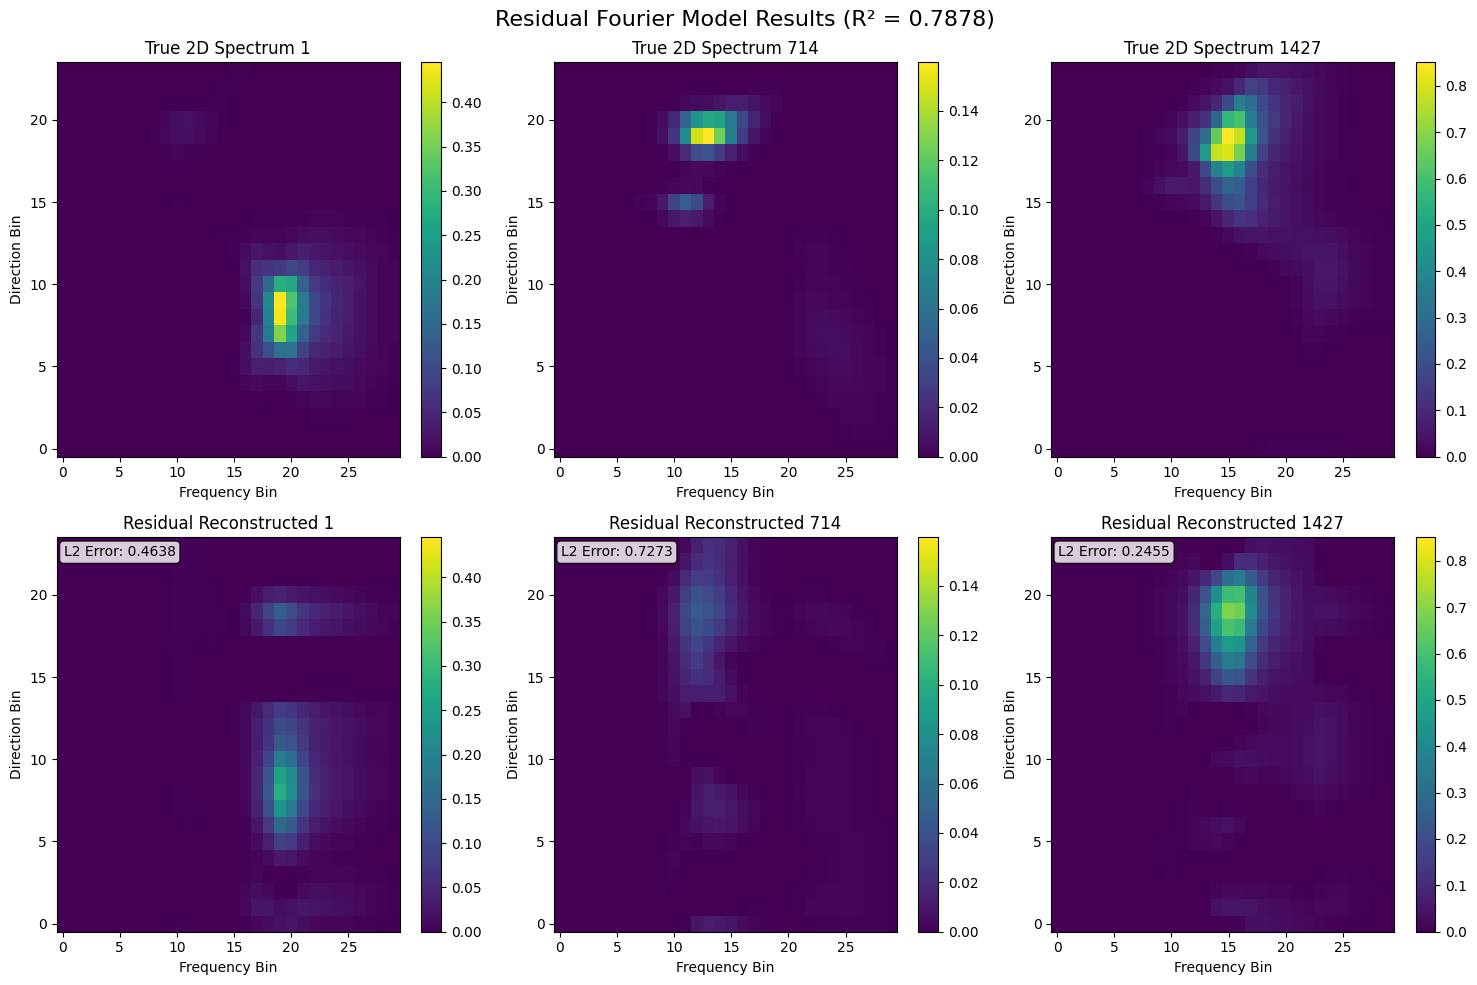

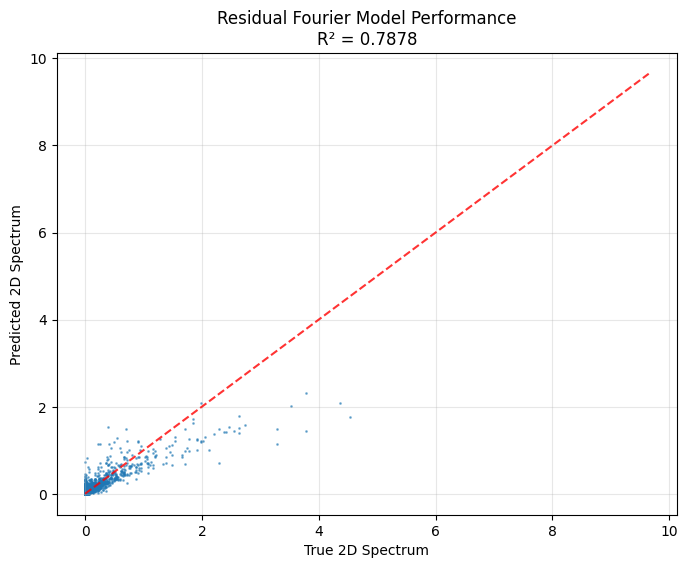


✅ Residual visualization completed!
Model successfully predicts residual higher-order Fourier coefficients
and reconstructs 2D spectra with R² = 0.7878


In [15]:
# Visualization: Compare true vs reconstructed spectra (residual approach)
print("Creating residual model visualization...")

# Select 3 examples for visualization 
sample_indices = [0, len(S2D_test_target)//2, len(S2D_test_target)-1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, idx in enumerate(sample_indices):
    # True spectrum (top row)
    true_spectrum = S2D_test_target[idx]
    pred_spectrum = S2D_reconstructed_np[idx]
    
    # Determine color scale
    vmax = max(true_spectrum.max(), pred_spectrum.max())
    
    # True spectrum
    im1 = axes[0, i].imshow(true_spectrum.T, aspect='auto', cmap='viridis', 
                           origin='lower', vmin=0, vmax=vmax)
    axes[0, i].set_title(f'True 2D Spectrum {idx+1}')
    axes[0, i].set_xlabel('Frequency Bin')
    axes[0, i].set_ylabel('Direction Bin')
    plt.colorbar(im1, ax=axes[0, i])
    
    # Predicted spectrum
    im2 = axes[1, i].imshow(pred_spectrum.T, aspect='auto', cmap='viridis',
                           origin='lower', vmin=0, vmax=vmax)
    axes[1, i].set_title(f'Residual Reconstructed {idx+1}')
    axes[1, i].set_xlabel('Frequency Bin')
    axes[1, i].set_ylabel('Direction Bin')
    plt.colorbar(im2, ax=axes[1, i])
    
    # Add error metrics as text
    sample_error = relative_l2_error[idx]
    axes[1, i].text(0.02, 0.98, f'L2 Error: {sample_error:.4f}', 
                    transform=axes[1, i].transAxes, fontsize=10,
                    verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(f'Residual Fourier Model Results (R² = {r2_res:.4f})', fontsize=16)
plt.tight_layout()
plt.show()

# Scatter plot for overall performance
plt.figure(figsize=(8, 6))
n_points = min(10000, len(y_true_flat))
indices = np.random.choice(len(y_true_flat), n_points, replace=False)

plt.scatter(y_true_flat[indices], y_pred_flat[indices], alpha=0.5, s=1)
plt.plot([y_true_flat.min(), y_true_flat.max()], [y_true_flat.min(), y_true_flat.max()], 'r--', alpha=0.8)
plt.xlabel('True 2D Spectrum')
plt.ylabel('Predicted 2D Spectrum')
plt.title(f'Residual Fourier Model Performance\nR² = {r2_res:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Residual visualization completed!")
print(f"Model successfully predicts residual higher-order Fourier coefficients")
print(f"and reconstructs 2D spectra with R² = {r2_res:.4f}")